In [1]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

## Information:
- Checkerboard: 10x7 -> inner corners:=(9x6)
- Square size by cm: 2.9 (using rules 30cm)

In [2]:
CALIB_DIR = "L02_calibration_img_lenx1-i14pro"
TEST_DIR = "L02_test_img_lenx1-i14pro"

CHECKERBOARD = (9, 6)  # inner corners
square_size = 2.9     # real dimension of a square, unit: cm

In [3]:
# Tạo tọa độ 3D thật của các góc checkerboard
# Vì checkerboard là mặt phẳng nên z = 0
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)

objp[:, :2] = np.mgrid[
    0:CHECKERBOARD[0],
    0:CHECKERBOARD[1]
].T.reshape(-1, 2)

objp = objp * square_size

objpoints = []  # 3D points thật
imgpoints = []  # 2D points trên ảnh

In [4]:
image_paths = sorted(glob.glob(os.path.join(CALIB_DIR, "*")))

print("Number of calibration images:", len(image_paths))
print(image_paths[:5])

Number of calibration images: 38
['L02_calibration_img_lenx1-i14pro/img_01.jpg', 'L02_calibration_img_lenx1-i14pro/img_02.jpg', 'L02_calibration_img_lenx1-i14pro/img_03.jpg', 'L02_calibration_img_lenx1-i14pro/img_04.jpg', 'L02_calibration_img_lenx1-i14pro/img_05.jpg']


Image shape: (4032, 3024, 3)
Gray min: 0
Gray max: 255
Gray mean: 150.7088151763406


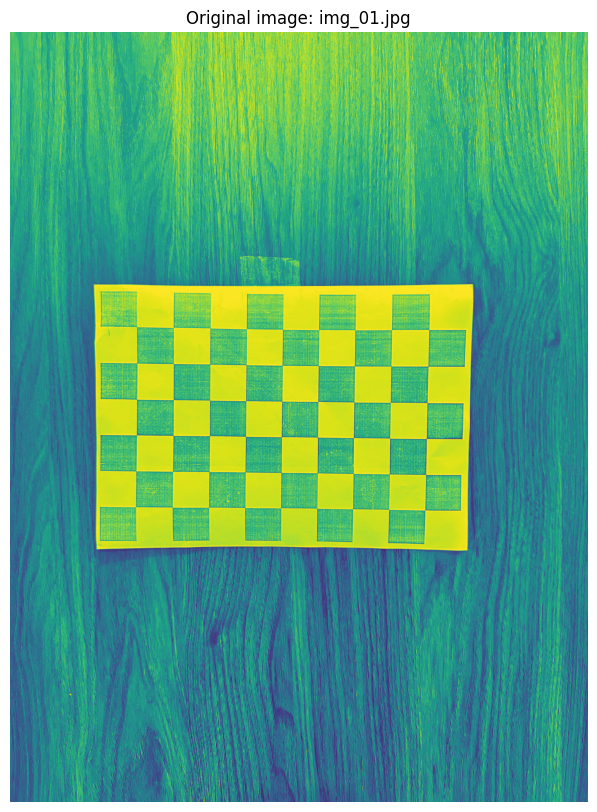

In [80]:
img_path = os.path.join(CALIB_DIR, "img_01.jpg")

img = cv2.imread(img_path)

if img is None:
    raise ValueError(f"Cannot read image: {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Image shape:", img.shape)
print("Gray min:", gray.min())
print("Gray max:", gray.max())
print("Gray mean:", gray.mean())

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
plt.title("Original image: img_01.jpg")
plt.axis("off")
plt.show()

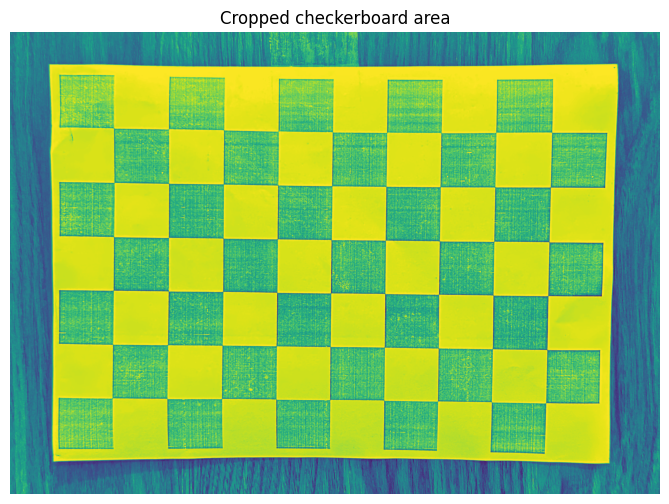

Crop shape: (1613, 2268, 3)
Crop gray min: 0
Crop gray max: 255
Crop gray mean: 182.97320629016227


In [95]:
h, w = img.shape[:2]

# Crop vùng giữa ảnh, có thể chỉnh nếu cần
crop = img[int(h*0.3):int(h*0.7), int(w*0.1):int(w*0.85)]
crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(crop_gray)
plt.title("Cropped checkerboard area")
plt.axis("off")
plt.show()

print("Crop shape:", crop.shape)
print("Crop gray min:", crop_gray.min())
print("Crop gray max:", crop_gray.max())
print("Crop gray mean:", crop_gray.mean())

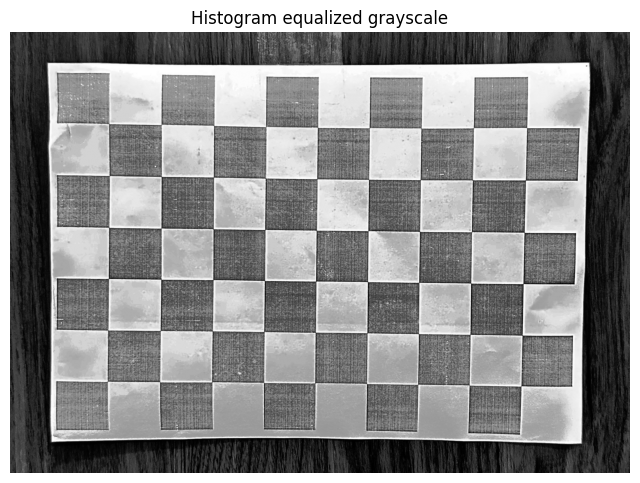

SB detector after equalizeHist: True


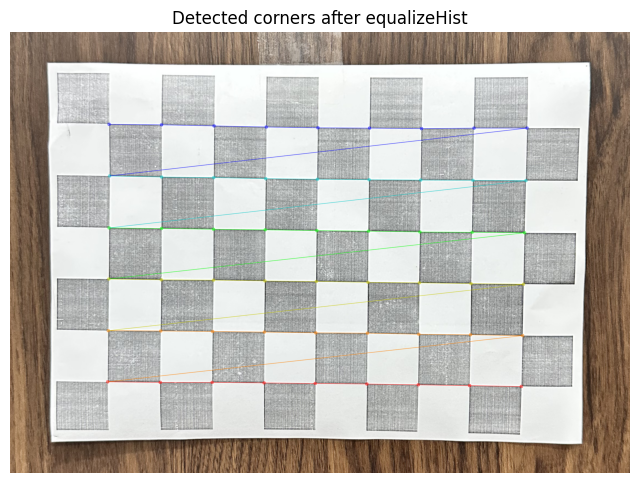

In [96]:
gray_eq = cv2.equalizeHist(crop_gray)

plt.figure(figsize=(8, 10))
plt.imshow(gray_eq, cmap="gray")
plt.title("Histogram equalized grayscale")
plt.axis("off")
plt.show()

ret_eq, corners_eq = cv2.findChessboardCornersSB(gray_eq, CHECKERBOARD)

print("SB detector after equalizeHist:", ret_eq)

if ret_eq:
    img_draw_eq = crop.copy()
    cv2.drawChessboardCorners(img_draw_eq, CHECKERBOARD, corners_eq, ret_eq)

    plt.figure(figsize=(8, 10))
    plt.imshow(cv2.cvtColor(img_draw_eq, cv2.COLOR_BGR2RGB))
    plt.title("Detected corners after equalizeHist")
    plt.axis("off")
    plt.show()